In [1]:
!python -m pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   ---------------------------------------- 0/2 [joblib]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -------------------- ------------------- 1/2 [scikit-learn]
   -----------------

In [2]:
import sklearn as sk
from sklearn.linear_model import LinearRegression
print(sk.__version__)

1.8.0


In [ ]:
# linear regression

# importing dependencies
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# fetching data and setting feature, target 
data = fetch_california_housing()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['Price'] = data.target
X = df[["MedInc"]] # feature
y = df["Price"] # target

# spliting data into test and validation set
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# training linear reg model
model = LinearRegression()
model.fit(train_X, train_y)

# making prediction
predictions = model.predict(val_X)

# model evaluation
mae = mean_absolute_error(val_y, predictions)
print("MAE", mae)

print("Slope: ", model.coef_[0])
print("Intercept: ", model.intercept_)


MAE 0.6246908572288111
Slope:  0.4223655000697582
Intercept:  0.43942693570586755


In [18]:
# multi-linear reg

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

data = fetch_california_housing()

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["Price"] = data.target

X = df[["MedInc", "HouseAge", "AveRooms", "AveBedrms"]] # feature
y = df["Price"] # target

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = LinearRegression()
model.fit(train_X, train_y)

predictions = model.predict(val_X)

print("MAE: ", mean_absolute_error(val_y, predictions))

MAE:  0.5770418685911077


In [20]:
# logistic regression

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df[["mean radius","mean texture"]]
y = df["target"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = LogisticRegression()
model.fit(train_X, train_y)

predictions = model.predict(val_X)

print("Accuracy:", accuracy_score(val_y, predictions))

Accuracy: 0.8601398601398601


Accuracy:  0.9736842105263158


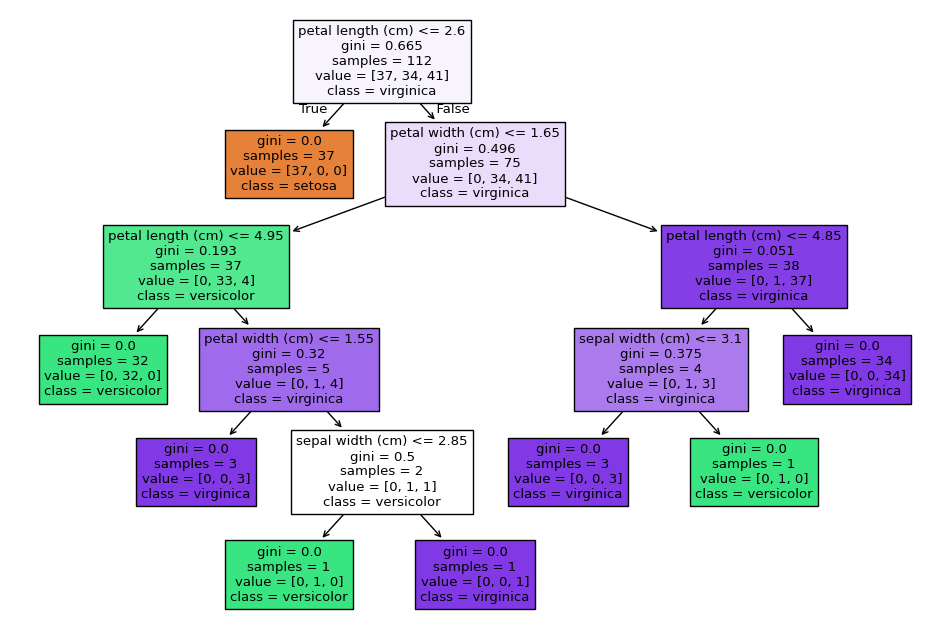

In [25]:
# decision tree

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target

X = df[data.feature_names]
y = df["target"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = DecisionTreeClassifier()
model.fit(train_X, train_y)
predictions = model.predict(val_X)

print("Accuracy: ", accuracy_score(val_y, predictions))
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()

In [26]:
# simple vector machine

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_iris()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df[data.feature_names]
y = df["target"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = SVC()
model.fit(train_X, train_y)

predictions = model.predict(val_X)
print("Accuracy:", accuracy_score(val_y, predictions))

Accuracy: 0.9736842105263158


In [27]:
# knn

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

data = load_iris()

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target

X = df[data.feature_names] #feature
y = df["target"] # target

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(train_X, train_y)

predictions = model.predict(val_X)

print("Accuracy:", accuracy_score(val_y, predictions))

Accuracy: 1.0


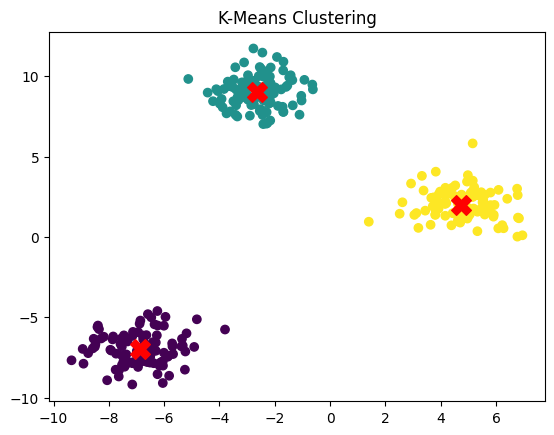

In [5]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Generate sample dataset
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

# Predicted clusters
labels = kmeans.labels_

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], 
            color='red', marker='X', s=200)

plt.title("K-Means Clustering")
plt.show()

Original (150, 4)
Reduced (150, 2)


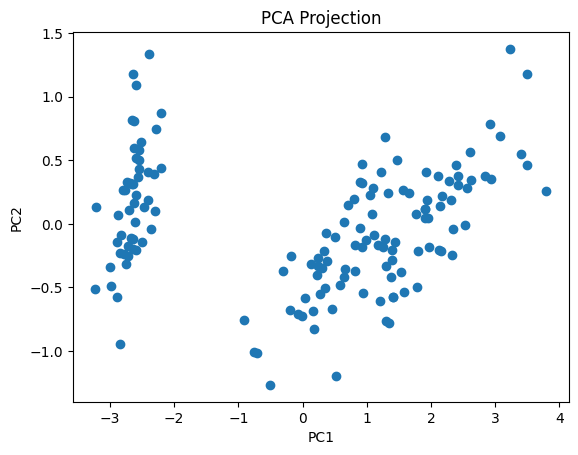

In [3]:
# principal component analysis

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = load_iris().data

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Original", X.shape)
print("Reduced", X_pca.shape)

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

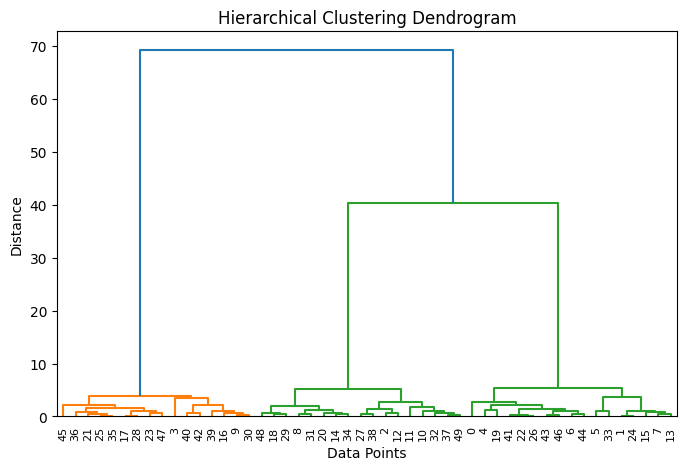

In [15]:
# Hierarchical Clustering

from sklearn.datasets import make_blobs # generating synthetic, multi-class datasets
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Generate sample dataset
X, y = make_blobs(n_samples=50, centers=3, random_state=42) 
Z = linkage(X, method="ward")

plt.figure(figsize=(8,5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

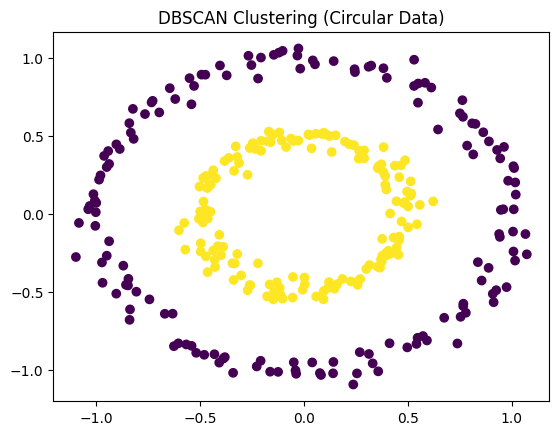

In [23]:
# Density based spatial clustering of applications with noise

from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate circular dataset
X, y = make_circles(n_samples=300, noise=0.05, factor=0.5)

# Apply DBSCAN
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

# Plot clusters
plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN Clustering (Circular Data)")
plt.show()

In [34]:
# silhouette score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate dataset
X, y = make_blobs(n_samples=200, centers=3, random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

# Calculate silhouette score
score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.8467003894636074
